**House Loan Data Analysis**

Objective: Create a model that predicts whether or not an applicant will be able to repay a loan using the historical data
Domain: Finance

Analysis to be done: Perform data preprocessing and build a deep learning prediction model



In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score,roc_curve
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



In [3]:
# Read Data from csv file.
df_load_data = pd.read_csv('/content/loan_data.csv')
df_load_data.head(10)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
5,1,credit_card,0.0788,125.13,11.904968,16.98,727,6120.041667,50807,51.0,0,0,0,0
6,1,debt_consolidation,0.1496,194.02,10.714418,4.00,667,3180.041667,3839,76.8,0,0,1,1
7,1,all_other,0.1114,131.22,11.002100,11.08,722,5116.000000,24220,68.6,0,0,0,1
8,1,home_improvement,0.1134,87.19,11.407565,17.25,682,3989.000000,69909,51.1,1,0,0,0
9,1,debt_consolidation,0.1221,84.12,10.203592,10.00,707,2730.041667,5630,23.0,1,0,0,0


In [4]:
# Basic EDA checks
df_load_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [5]:
df_load_data.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [6]:
df_load_data.isnull().sum()

,0
credit.policy,0
purpose,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0


# 3)	Print the percentage of default to a payer of the dataset for the TARGET column
# 5)	Plot the balanced or imbalanced data

not.fully.paid
0    83.994571
1    16.005429
Name: proportion, dtype: float64


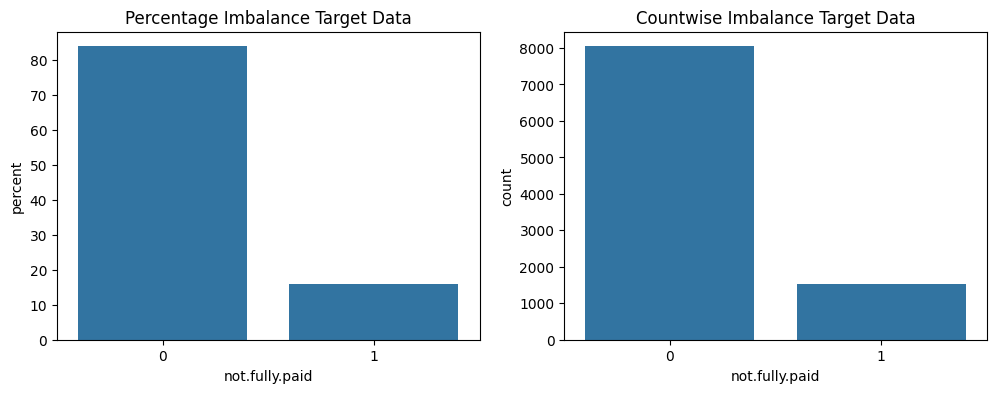

In [7]:
# 3)	Print the percentage of default to a payer of the dataset for the TARGET column
target_col_cnt = df_load_data['not.fully.paid'].value_counts(normalize=True) * 100
print(target_col_cnt)

# 5)	Plot the balanced or imbalanced data
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.countplot(x='not.fully.paid', data = df_load_data ,stat = 'percent')
plt.title('Percentage Imbalance Target Data' )

plt.subplot(1,2,2)
sns.countplot(x='not.fully.paid', data = df_load_data )
plt.title('Countwise Imbalance Target Data' )
plt.show()


2)	Check for null values in the dataset
Observations:
1. There is no null presents in the dataset

2. Column 'Pupose' is having dtype as Object needs encoding  One hot encoding is used as in labelencoding classes rouped as per numbers so due to  numbering model may interpret data as ordinal data which is not the case here so one hot encoding is prefered over label encoding in this user case.

3. Data is imbalanced in target column We can use SMOTE technique or use class_weight in SMOTE we need to adjust data but if we use class_weight it modifies the loss function during training, assigning a higher penalty for misclassifying minority class samples and a lower penalty for misclassifying majority class samples. This inherently focuses the model's learning on the under represented class without altering the dataset size, so its effecient way to handle imbalance datasets.

6)	Encode the columns that is required for the model

In [8]:
# --6)	Encode the columns that is required for the model
# encoding the Purpose column
purpose_dummies =pd.get_dummies(df_load_data['purpose'],drop_first =True)
purpose_dummies.head()


,credit_card,debt_consolidation,educational,home_improvement,major_purchase,small_business
0,False,True,False,False,False,False
1,True,False,False,False,False,False
2,False,True,False,False,False,False
3,False,True,False,False,False,False
4,True,False,False,False,False,False


In [9]:
# droping purpose column and concatenating dummy columns one hot encoded

df_load_data = pd.concat([df_load_data.drop(['purpose'],axis =1),purpose_dummies],axis =1)
df_load_data.head()


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,credit_card,debt_consolidation,educational,home_improvement,major_purchase,small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,True,False,False,False,False,False


In [10]:
# Preparing X,Y data set Feature/ Target Split
X = df_load_data.drop(['not.fully.paid'],axis =1)
Y = df_load_data['not.fully.paid']

In [11]:
# Train test data set :- Stratify used as dataset is imbalanced so to keep the proportion of data points same as original datasets
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2,random_state= 42,stratify= Y )

In [12]:
# doing standard scaling
scaler =StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

4)	Balance the dataset if the data is imbalanced

Class_weight is seems effective so applying to work on imbalance data.


In [13]:
class_weights = class_weight.compute_class_weight('balanced',classes = np.unique(y_train), y = y_train)

In [14]:
class_weights

array([0.59524549, 3.12479608])

In [15]:
class_weights=dict(enumerate(class_weights))
print("\n Class Weights:", class_weights)


 Class Weights: {0: np.float64(0.5952454940957116), 1: np.float64(3.124796084828711)}


0 is Major class so minimum weight is applied for 1 MInority class higher weight is assigned as data is less below image will show value_counts of classes.

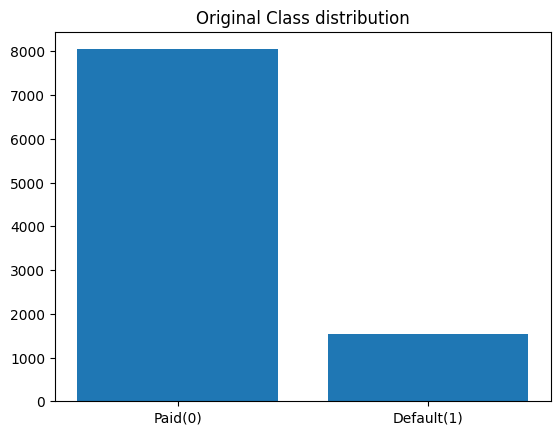

In [16]:
#plot the balanced data conceptually
labels=["Paid(0)","Default(1)"]
plt.bar(labels, Y.value_counts())
plt.title("Original Class distribution")
plt.show()

In [17]:
# BUilding Module
model = tf.keras.Sequential([
# Input layer
    tf.keras.layers.Input(shape = (x_train_sc.shape[1],)),

# 1st Hidden Layer
    tf.keras.layers.Dense(64,activation= 'relu'),
    tf.keras.layers.Dropout(0.2),
# 2nd Hidden Layer
    tf.keras.layers.Dense(32,activation= 'relu'),
    tf.keras.layers.Dropout(0.2),
# 3rd Hidden Layer
    tf.keras.layers.Dense(16,activation = 'relu'),
    tf.keras.layers.Dropout(0.2),
# Ouput Layer --Since its binary classification actfn used is Sigmoid for multi class Softmax can be used
    tf.keras.layers.Dense(1,activation = 'sigmoid')

])

model.compile(optimizer = 'adam',loss = "binary_crossentropy",metrics = ['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Train the model with Training Data
early_stop = EarlyStopping(monitor = 'val_loss',patience =5,restore_best_weights= True)
history = model.fit(x_train_sc,y_train,validation_split=0.3,epochs = 50, class_weight = class_weights, callbacks = [early_stop] , batch_size = 64 ,verbose = 1)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.6725 - loss: 0.7260 - val_accuracy: 0.4793 - val_loss: 0.6917
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5784 - loss: 0.6721 - val_accuracy: 0.4915 - val_loss: 0.6833
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5403 - loss: 0.6807 - val_accuracy: 0.5650 - val_loss: 0.6401
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5927 - loss: 0.6457 - val_accuracy: 0.5080 - val_loss: 0.6760
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5451 - loss: 0.6725 - val_accuracy: 0.5398 - val_loss: 0.6553
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5761 - loss: 0.6567 - val_accuracy: 0.5407 - val_loss: 0.6509
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5778 - loss: 0.6445 - val_accuracy: 0.5394 - val_loss: 0.6523
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5622 - loss: 0.6476 - val_accuracy: 0.5137 - val_loss

In [19]:
# Model Prediction
y_predict_prob=model.predict(x_test_sc)
y_pred=(y_predict_prob>0.5).astype(int)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [20]:
# confusion matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)
print("Classification Report")
print(classification_report(y_test,y_pred))

[[873 736]
 [ 96 211]]
Classification Report
              precision    recall  f1-score   support

           0       0.90      0.54      0.68      1609
           1       0.22      0.69      0.34       307

    accuracy                           0.57      1916
   macro avg       0.56      0.61      0.51      1916
weighted avg       0.79      0.57      0.62      1916



In [21]:
# calculate senstivity scores
#Senstivity= TP /(TP+FN)

TP=cm[1,1]
FN=cm[1,0]
senstivity=TP/(TP+FN)
print("Senstivity Score:",senstivity)

Senstivity Score: 0.6872964169381107


ROC-AUC Score: 0.677625652123742


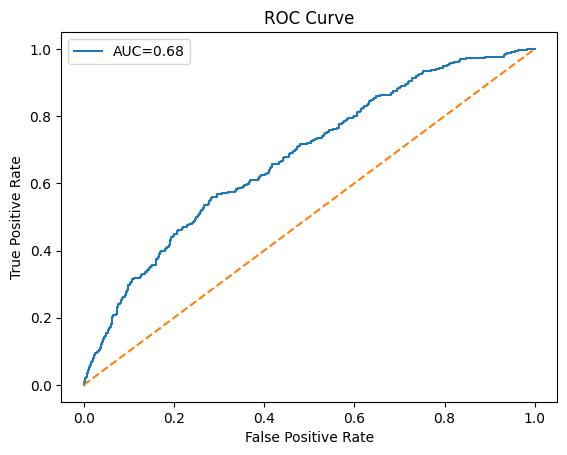

In [22]:
#. ROC-AUC Score
roc_auc=roc_auc_score(y_test,y_predict_prob)
print("ROC-AUC Score:",roc_auc)

fpr,tpr,_=roc_curve(y_test,y_predict_prob)
plt.plot(fpr,tpr,label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

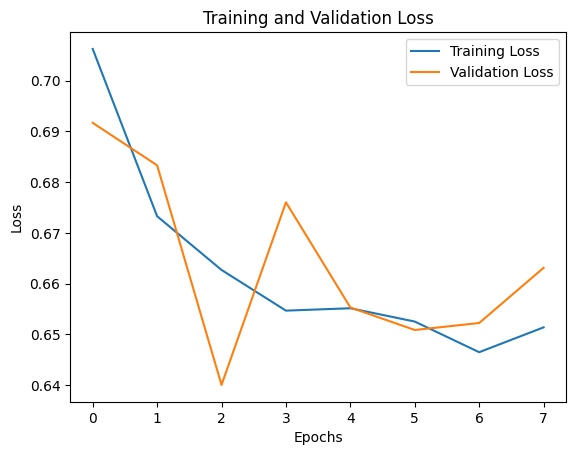

In [23]:
# Training history visualisation --# loss plot

plt.plot(history.history['loss'],label="Training Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


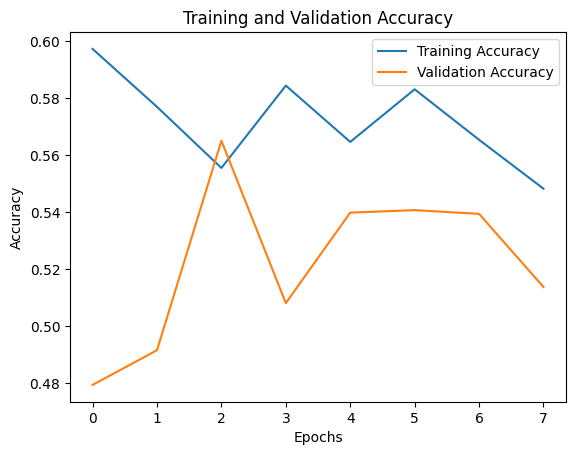

In [24]:
#accuracyt plot
plt.plot(history.history['accuracy'],label="Training Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()